In [ ]:
import os
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml

from dataset import TKGDataset
from evaluators import evaluation, valid
from training import Logger, OracleTrainer, Trainer
from utils import *

In [29]:
# Model configuration
MODEL_CONFIG = {
    'embedding_dim': 200,
    'dropout': 0.5,
    'alpha': 0.2,
    'lambdax': 10,
    'oracle_mode': 'soft',
    'filtering': True,
}

# Training configuration
TRAINING_CONFIG = {
    'dataset_name': 'YAGO',  # Change to: 'GDELT', 'ICEWS14', 'ICEWS18', 'WIKI'
    'batch_size': 1024,
    'max_epochs': 1,
    'oracle_epochs': 1,
    'valid_epochs': 1,
    'lr': 0.001,
    'oracle_lr': 0.001,
    'weight_decay': 1.0e-05,
    'use_seed': True,
    'seed': 987,
}

# System configuration
SYSTEM_CONFIG = {
    'gpu_id': '0',
    'use_cuda': True,
    'only_oracle': False,
    'only_eva': False,
    'save_dir': 'SAVE',
    'model_dir': '',
}

# Dataset-specific configurations (overrides defaults)
DATASET_CONFIGS = {
    'YAGO': {
        'dataset': 'YAGO',
        'description': 'yago_hard',
        'model': {
            'alpha': 0.2,
            'lambdax': 2,
            'oracle_mode': 'hard',
        }
    },
    'GDELT': {
        'dataset': 'GDELT',
        'description': 'gdelt_default',
    },
    'ICEWS14': {
        'dataset': 'ICEWS14',
        'description': 'icews14_default',
    },
    'ICEWS18': {
        'dataset': 'ICEWS18',
        'description': 'icews18_default',
        'model': {
            'alpha': 0.2,
            'lambdax': 2,
            'oracle_mode': 'soft',
        }
    },
    'WIKI': {
        'dataset': 'WIKI',
        'description': 'wiki_default',
    },
}

In [30]:
class Oracle(nn.Module):
    def __init__(self, input_dim, out_dim):
        super(Oracle, self).__init__()
        self.linear = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2),
            nn.Linear(input_dim, out_dim)
        )

    def forward(self, x):
        return self.linear(x)

In [31]:
class CENET(nn.Module):
    def __init__(self, num_e, num_rel, num_t, embedding_dim, dropout, lambdax, alpha, oracle_mode, filtering):
        super(CENET, self).__init__()
        # stats
        self.num_e = num_e
        self.num_t = num_t
        self.num_rel = num_rel
        self.embedding_dim = embedding_dim
        self.lambdax = lambdax
        self.alpha = alpha
        self.oracle_mode = oracle_mode
        self.filtering = filtering

        # Precomputed triple indexes.
        self._so_index: dict = {}
        self._os_index: dict = {}
        self._so_index_device_cache: dict = {}
        self._os_index_device_cache: dict = {}

        # entity relation embedding
        self.rel_embeds = nn.Parameter(torch.zeros(2 * num_rel, embedding_dim))
        self.entity_embeds = nn.Parameter(torch.zeros(self.num_e, embedding_dim))

        self.linear_frequency = nn.Linear(self.num_e, embedding_dim)

        self.contrastive_hidden_layer = nn.Linear(3 * embedding_dim, embedding_dim)
        self.oracle_layer = Oracle(3 * embedding_dim, 1)

        self.linear_pred_layer_s1 = nn.Linear(2 * embedding_dim, embedding_dim)
        self.linear_pred_layer_o1 = nn.Linear(2 * embedding_dim, embedding_dim)

        self.linear_pred_layer_s2 = nn.Linear(2 * embedding_dim, embedding_dim)
        self.linear_pred_layer_o2 = nn.Linear(2 * embedding_dim, embedding_dim)

        # Initialize weights and embeddings
        self.reset_parameters()

        self.dropout = nn.Dropout(dropout)
        self.tanh = nn.Tanh()
        self.crossEntropy = nn.BCELoss()

    def reset_parameters(self):
        gain = nn.init.calculate_gain('relu')

        # Initialize embeddings
        nn.init.xavier_uniform_(self.rel_embeds, gain=gain)
        nn.init.xavier_uniform_(self.entity_embeds, gain=gain)

        # Initialize layers
        self.weights_init(self.linear_frequency)
        self.weights_init(self.linear_pred_layer_s1)
        self.weights_init(self.linear_pred_layer_o1)
        self.weights_init(self.linear_pred_layer_s2)
        self.weights_init(self.linear_pred_layer_o2)
        self.oracle_layer.apply(self.weights_init)

    @staticmethod
    def weights_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))

    def build_triple_index(self, all_triples: torch.Tensor):
        so_index: dict = defaultdict(list)
        os_index: dict = defaultdict(list)

        triples_cpu = all_triples.cpu()
        s_col = triples_cpu[:, 0].tolist()
        r_col = triples_cpu[:, 1].tolist()
        o_col = triples_cpu[:, 2].tolist()

        for s, r, o in zip(s_col, r_col, o_col):
            so_index[(s, r)].append(o)
            os_index[(o, r)].append(s)

        self._so_index = {k: torch.tensor(v, dtype=torch.long) for k, v in so_index.items()}
        self._os_index = {k: torch.tensor(v, dtype=torch.long) for k, v in os_index.items()}
        self._so_index_device_cache = {}
        self._os_index_device_cache = {}

    def _get_index_on_device(self, index_name: str, key, device):
        if index_name == 'so':
            index = self._so_index
            cache = self._so_index_device_cache
        else:
            index = self._os_index
            cache = self._os_index_device_cache

        idx = index.get(key, None)
        if idx is None:
            return None

        cache_key = (device.type, device.index, key)
        idx_device = cache.get(cache_key, None)
        if idx_device is None:
            idx_device = idx.to(device, non_blocking=True)
            cache[cache_key] = idx_device
        return idx_device

    def history_and_non_history_depedency(self, s_frequency, o_frequency, lambdax):
        s_history_tag = s_frequency.clone()
        o_history_tag = o_frequency.clone()
        s_non_history_tag = s_frequency.clone()
        o_non_history_tag = o_frequency.clone()

        s_history_tag[s_history_tag != 0] = lambdax
        o_history_tag[o_history_tag != 0] = lambdax

        s_non_history_tag[s_history_tag == 1] = -lambdax
        s_non_history_tag[s_history_tag == 0] = lambdax

        o_non_history_tag[o_history_tag == 1] = -lambdax
        o_non_history_tag[o_history_tag == 0] = lambdax

        s_history_tag[s_history_tag == 0] = -lambdax
        o_history_tag[o_history_tag == 0] = -lambdax

        return s_history_tag, o_history_tag, s_non_history_tag, o_non_history_tag

    def forward(self, batch_block, mode_lk, total_data=None):
        quadruples, s_history_event_o, o_history_event_s, \
        s_history_label_true, o_history_label_true, s_frequency, o_frequency = batch_block

        if isListEmpty(s_history_event_o) or isListEmpty(o_history_event_s):
            return (None, None) if mode_lk in ['Valid', 'Test'] else None

        s, r, o = quadruples[:, :3].T
        s_history_tag, o_history_tag, \
            s_non_history_tag, o_non_history_tag = self.history_and_non_history_depedency(
                s_frequency, o_frequency, self.lambdax)

        s_frequency = F.softmax(s_frequency, dim=1)
        o_frequency = F.softmax(o_frequency, dim=1)
        s_frequency_hidden = self.tanh(self.linear_frequency(s_frequency))
        o_frequency_hidden = self.tanh(self.linear_frequency(o_frequency))

        if mode_lk == 'Training':
            s_nce_loss, _ = self.calculate_nce_loss(s, o, r, self.rel_embeds[:self.num_rel],
                                                    self.linear_pred_layer_s1, self.linear_pred_layer_s2,
                                                    s_history_tag, s_non_history_tag, return_preds=False)
            o_nce_loss, _ = self.calculate_nce_loss(o, s, r, self.rel_embeds[self.num_rel:],
                                                    self.linear_pred_layer_o1, self.linear_pred_layer_o2,
                                                    o_history_tag, o_non_history_tag, return_preds=False)
            s_spc_loss = self.calculate_spc_loss(s, r, self.rel_embeds[:self.num_rel],
                                                 s_history_label_true, s_frequency_hidden)
            o_spc_loss = self.calculate_spc_loss(o, r, self.rel_embeds[self.num_rel:],
                                                 o_history_label_true, o_frequency_hidden)
            nce_loss = (s_nce_loss + o_nce_loss) / 2.0
            spc_loss = (s_spc_loss + o_spc_loss) / 2.0
            return self.alpha * nce_loss + (1 - self.alpha) * spc_loss

        elif mode_lk in ['Valid', 'Test']:
            s_history_oid = []
            o_history_sid = []

            for i in range(quadruples.shape[0]):
                s_history_oid.append([])
                o_history_sid.append([])
                for con_events in s_history_event_o[i]:
                    s_history_oid[-1] += con_events[:, 1].tolist()
                for con_events in o_history_event_s[i]:
                    o_history_sid[-1] += con_events[:, 1].tolist()

            s_nce_loss, s_preds = self.calculate_nce_loss(s, o, r, self.rel_embeds[:self.num_rel],
                                                          self.linear_pred_layer_s1, self.linear_pred_layer_s2,
                                                          s_history_tag, s_non_history_tag)
            o_nce_loss, o_preds = self.calculate_nce_loss(o, s, r, self.rel_embeds[self.num_rel:],
                                                          self.linear_pred_layer_o1, self.linear_pred_layer_o2,
                                                          o_history_tag, o_non_history_tag)

            s_ce_loss, s_pred_history_label, s_ce_all_acc = self.oracle_loss(s, r, self.rel_embeds[:self.num_rel],
                                                                              s_history_label_true, s_frequency_hidden)
            o_ce_loss, o_pred_history_label, o_ce_all_acc = self.oracle_loss(o, r, self.rel_embeds[self.num_rel:],
                                                                              o_history_label_true, o_frequency_hidden)

            s_mask = self._build_mask_vectorized(quadruples, s_pred_history_label, s_history_oid)
            o_mask = self._build_mask_vectorized(quadruples, o_pred_history_label, o_history_sid)

            if self.oracle_mode == 'soft':
                s_mask = F.softmax(s_mask, dim=1)
                o_mask = F.softmax(o_mask, dim=1)

            s_total_loss1, sub_rank1 = self.link_predict(s_nce_loss, s_preds, s_ce_loss, s, o, r,
                                                         s_mask, total_data, 's', True)
            o_total_loss1, obj_rank1 = self.link_predict(o_nce_loss, o_preds, o_ce_loss, o, s, r,
                                                         o_mask, total_data, 'o', True)
            batch_loss1 = (s_total_loss1 + o_total_loss1) / 2.0

            s_total_loss2, sub_rank2 = self.link_predict(s_nce_loss, s_preds, s_ce_loss, s, o, r,
                                                         s_mask, total_data, 's', False)
            o_total_loss2, obj_rank2 = self.link_predict(o_nce_loss, o_preds, o_ce_loss, o, s, r,
                                                         o_mask, total_data, 'o', False)
            batch_loss2 = (s_total_loss2 + o_total_loss2) / 2.0

            s_mask_gt = self._build_mask_gt_vectorized(quadruples, o, s_history_oid)
            o_mask_gt = self._build_mask_gt_vectorized(quadruples, s, o_history_sid)

            s_total_loss3, sub_rank3 = self.link_predict(s_nce_loss, s_preds, s_ce_loss, s, o, r,
                                                         s_mask_gt, total_data, 's', True)
            o_total_loss3, obj_rank3 = self.link_predict(o_nce_loss, o_preds, o_ce_loss, o, s, r,
                                                         o_mask_gt, total_data, 'o', True)
            batch_loss3 = (s_total_loss3 + o_total_loss3) / 2.0

            return sub_rank1, obj_rank1, batch_loss1, \
                   sub_rank2, obj_rank2, batch_loss2, \
                   sub_rank3, obj_rank3, batch_loss3, \
                   (s_ce_all_acc + o_ce_all_acc) / 2

        elif mode_lk == 'Oracle':
            s_ce_loss, _, _ = self.oracle_loss(s, r, self.rel_embeds[:self.num_rel],
                                               s_history_label_true, s_frequency_hidden)
            o_ce_loss, _, _ = self.oracle_loss(o, r, self.rel_embeds[self.num_rel:],
                                               o_history_label_true, o_frequency_hidden)
            return (s_ce_loss + o_ce_loss) / 2.0 + self.oracle_l1(0.01)

    def _build_history_mask(self, history_ids: list, device) -> torch.Tensor:
        B = len(history_ids)
        history_mask = torch.zeros(B, self.num_e, device=device)

        row_parts = []
        col_parts = []
        for i, ids in enumerate(history_ids):
            if len(ids) == 0:
                continue
            ids_tensor = torch.as_tensor(ids, dtype=torch.long, device=device)
            row_parts.append(torch.full_like(ids_tensor, i))
            col_parts.append(ids_tensor)

        if row_parts:
            rows = torch.cat(row_parts)
            cols = torch.cat(col_parts)
            history_mask[rows, cols] = 1.0

        return history_mask

    def _build_mask_vectorized(
        self,
        quadruples: torch.Tensor,
        pred_label: torch.Tensor,
        history_ids: list,
    ) -> torch.Tensor:
        device = quadruples.device
        history_mask = self._build_history_mask(history_ids, device)

        is_history = torch.squeeze(pred_label) > 0.5
        if is_history.dim() == 0:
            is_history = is_history.unsqueeze(0)

        return torch.where(is_history.unsqueeze(1), history_mask, 1.0 - history_mask)

    def _build_mask_gt_vectorized(
        self,
        quadruples: torch.Tensor,
        actor2: torch.Tensor,
        history_ids: list,
    ) -> torch.Tensor:
        device = quadruples.device
        history_mask = self._build_history_mask(history_ids, device)
        in_history = history_mask[torch.arange(actor2.shape[0], device=device), actor2].bool()

        return torch.where(in_history.unsqueeze(1), history_mask, 1.0 - history_mask)

    def oracle_loss(self, actor1, r, rel_embeds, history_label, frequency_hidden):
        history_label_pred = torch.sigmoid(
            self.oracle_layer(torch.cat((self.entity_embeds[actor1], rel_embeds[r], frequency_hidden), dim=1)))
        true_label = torch.squeeze(history_label)
        pred_label = (torch.squeeze(history_label_pred) > 0.5).to(true_label.dtype)
        ce_correct = torch.sum(torch.eq(pred_label, true_label))
        ce_loss = self.crossEntropy(torch.squeeze(history_label_pred), true_label)
        return ce_loss, history_label_pred, ce_correct.item()

    def calculate_nce_loss(
        self,
        actor1,
        actor2,
        r,
        rel_embeds,
        linear1,
        linear2,
        history_tag,
        non_history_tag,
        return_preds=True,
    ):
        preds_raw1 = self.tanh(linear1(
            self.dropout(torch.cat((self.entity_embeds[actor1], rel_embeds[r]), dim=1))))
        logits1 = preds_raw1.mm(self.entity_embeds.transpose(0, 1)) + history_tag

        preds_raw2 = self.tanh(linear2(
            self.dropout(torch.cat((self.entity_embeds[actor1], rel_embeds[r]), dim=1))))
        logits2 = preds_raw2.mm(self.entity_embeds.transpose(0, 1)) + non_history_tag

        actor2 = actor2.view(-1, 1)

        if return_preds:
            preds1 = F.softmax(logits1, dim=1)
            preds2 = F.softmax(logits2, dim=1)
            target_prob = torch.gather(preds1, 1, actor2) + torch.gather(preds2, 1, actor2)
            nce = -torch.mean(torch.log(target_prob))
            return nce, preds1 + preds2

        target_logit1 = torch.gather(logits1, 1, actor2)
        target_logit2 = torch.gather(logits2, 1, actor2)
        target_log_prob1 = target_logit1 - torch.logsumexp(logits1, dim=1, keepdim=True)
        target_log_prob2 = target_logit2 - torch.logsumexp(logits2, dim=1, keepdim=True)
        nce = -torch.mean(torch.logaddexp(target_log_prob1, target_log_prob2))
        return nce, None

    def link_predict(self, nce_loss, preds, ce_loss, actor1, actor2, r, trust_musk, all_triples, pred_known, oracle):
        if oracle:
            preds = torch.mul(preds, trust_musk)

        total_loss = nce_loss + ce_loss
        grounds = preds[torch.arange(preds.shape[0], device=preds.device), actor2]

        if self.filtering:
            if len(self._so_index) == 0 and all_triples is not None:
                self.build_triple_index(all_triples)

            index_name = 'so' if pred_known == 's' else 'os'
            preds = preds.clone()

            actor1_list = actor1.detach().cpu().tolist()
            r_list = r.detach().cpu().tolist()

            for i, (cur_actor1, cur_r) in enumerate(zip(actor1_list, r_list)):
                idx = self._get_index_on_device(index_name, (cur_actor1, cur_r), preds.device)
                if idx is not None and idx.numel() > 0:
                    preds[i].index_fill_(0, idx, 0.0)

            preds[torch.arange(preds.shape[0], device=preds.device), actor2] = grounds

        grounds = grounds.unsqueeze(1)
        comp1 = (preds > grounds).sum(dim=1).float()
        comp2 = (preds == grounds).sum(dim=1).float()
        ranks = (comp1 + (comp2 - 1.0) / 2.0 + 1.0).cpu().tolist()

        return total_loss, ranks

    def oracle_l1(self, reg_param):
        reg = 0
        for param in self.oracle_layer.parameters():
            reg += torch.sum(torch.abs(param))
        return reg * reg_param

    def freeze_parameter(self):
        self.rel_embeds.requires_grad_(False)
        self.entity_embeds.requires_grad_(False)
        self.linear_pred_layer_s1.requires_grad_(False)
        self.linear_pred_layer_o1.requires_grad_(False)
        self.linear_pred_layer_s2.requires_grad_(False)
        self.linear_pred_layer_o2.requires_grad_(False)
        self.linear_frequency.requires_grad_(False)
        self.contrastive_hidden_layer.requires_grad_(False)

    def contrastive_layer(self, x):
        x = self.contrastive_hidden_layer(x)
        return x

    def calculate_spc_loss(self, actor1, r, rel_embeds, targets, frequency_hidden):
        projections = self.contrastive_layer(
            torch.cat((self.entity_embeds[actor1], rel_embeds[r], frequency_hidden), dim=1))
        targets = torch.squeeze(targets)
        dot_product_tempered = torch.mm(projections, projections.T) / 1.0
        exp_dot_tempered = torch.exp(
            dot_product_tempered - torch.max(dot_product_tempered, dim=1, keepdim=True)[0]) + 1e-5
        mask_similar_class = targets.unsqueeze(1) == targets.unsqueeze(0)
        mask_anchor_out = ~torch.eye(exp_dot_tempered.shape[0], dtype=torch.bool, device=projections.device)
        mask_combined = mask_similar_class * mask_anchor_out
        cardinality_per_samples = torch.sum(mask_combined, dim=1)
        log_prob = -torch.log(exp_dot_tempered / (torch.sum(exp_dot_tempered * mask_anchor_out, dim=1, keepdim=True)))
        supervised_contrastive_loss_per_sample = torch.sum(log_prob * mask_combined, dim=1) / cardinality_per_samples

        supervised_contrastive_loss = torch.mean(supervised_contrastive_loss_per_sample)
        if torch.any(torch.isnan(supervised_contrastive_loss)):
            return 0
        return supervised_contrastive_loss

In [32]:
# Extract dataset name from config
dataset_name = TRAINING_CONFIG['dataset_name']

# Get configs from dictionaries by passing them as parameters
model_config, training_config, system_config = get_configs(
    dataset_name, 
    MODEL_CONFIG, 
    TRAINING_CONFIG, 
    SYSTEM_CONFIG, 
    DATASET_CONFIGS
)

# Setup GPU/CPU
use_cuda = system_config['use_cuda'] and torch.cuda.is_available()
system_config['use_cuda'] = use_cuda
device = torch.device(f'cuda:{system_config["gpu_id"]}' if use_cuda else 'cpu')

# Setup seed if enabled
if training_config['use_seed']:
    seed = training_config['seed']
    np.random.seed(seed)
    torch.manual_seed(seed)
    print(f"Seed set to: {seed}")

# Setup directories
os.makedirs(system_config['save_dir'], exist_ok=True)

print(f"Dataset: {system_config['dataset']}")
print(f"Device: {device}")
print(f"CUDA available: {use_cuda}")

Seed set to: 987
Dataset: YAGO
Device: cuda:0
CUDA available: True


In [33]:
dataset = TKGDataset(system_config['dataset'])
num_nodes = dataset.num_nodes
num_rels = dataset.num_rels
num_t = dataset.num_t

print(f"Nodes: {num_nodes}, Relations: {num_rels}, Timestamps: {num_t}")

Nodes: 10623, Relations: 10, Timestamps: 189


In [34]:
trainer = None
test_logger = None

if not system_config['only_eva'] and not system_config['only_oracle']:
    # Create model
    model = CENET(
        num_nodes,
        num_rels,
        num_t,
        embedding_dim=model_config['embedding_dim'],
        dropout=model_config['dropout'],
        lambdax=model_config['lambdax'],
        alpha=model_config['alpha'],
        oracle_mode=model_config['oracle_mode'],
        filtering=model_config['filtering'],
    )
    
    # Setup optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=training_config['lr'],
        weight_decay=training_config['weight_decay']
    )
    model = model.to(device)
    
    # Create trainer
    trainer = Trainer(
        model, optimizer, training_config, dataset,
        num_rels, num_nodes, num_t,
        save_dir=system_config['save_dir'],
        dataset_name=system_config['dataset'],
        use_cuda=use_cuda,
        device=device
    )
    trainer.log_config(model_config, training_config, system_config)
    trainer.log_model_info()
    model_path = trainer.train()
    main_dirName = os.path.dirname(model_path)
    test_logger = trainer.get_logger()
else:
    # Load existing model
    main_dirName = os.path.join(system_config['save_dir'], system_config['model_dir'])
    model_path = os.path.join(main_dirName, 'models')
    logger_instance = Logger(system_config['save_dir'], system_config['dataset'])
    test_logger = logger_instance
    main_dirName = logger_instance.get_log_dir()

print(f"Model path: {model_path}")

Model Configuration:
  alpha                = 0.2
  dropout              = 0.5
  embedding_dim        = 200
  filtering            = True
  lambdax              = 2
  oracle_mode          = hard
Training Configuration:
  batch_size           = 1024
  dataset_name         = YAGO
  lr                   = 0.001
  max_epochs           = 1
  oracle_epochs        = 1
  oracle_lr            = 0.001
  seed                 = 987
  use_seed             = True
  valid_epochs         = 1
  weight_decay         = 1e-05
System Configuration:
  dataset              = YAGO
  gpu_id               = 0
  model_dir            = 
  only_eva             = False
  only_oracle          = False
  save_dir             = SAVE
  use_cuda             = True

Model Information:
  Total Parameters: 5,056,801
  Trainable Parameters: 5,056,801
  GPU Memory Reserved:  0.15 GB
  GPU Memory Allocated: 0.08 GB
  GPU Memory Peak:      0.08 GB
Epoch 1/1


Training Epoch 1:   0%|          | 0/158 [00:00<?, ?batch/s]

Training Epoch 1: 100%|██████████| 158/158 [00:04<00:00, 36.89batch/s, loss=5.8425, avg_loss=5.9239]


[TRAIN] Epoch 1: Loss = 5.923944 (Time: 4.29s)
[VRAM] Peak: 0.20GB | Reserved: 0.23GB
[VALIDATION] Epoch 1


Validating: 100%|██████████| 20/20 [00:03<00:00,  5.25batch/s]

  [No Oracle Filtering]
    Subject test MRR (lk): 0.816529
    Subject test MR (lk): 224.699022
    Subject test Hits (lk) @ 1: 0.802284
    Subject test Hits (lk) @ 3: 0.821185
    Subject test Hits (lk) @ 10: 0.842340
    Object test MRR (lk): 0.828373
    Object test MR (lk): 274.914229
    Object test Hits (lk) @ 1: 0.822005
    Object test Hits (lk) @ 3: 0.829586
    Object test Hits (lk) @ 10: 0.838601
    ALL test MRR (lk): 0.822451
    ALL test MR (lk): 249.806626
    ALL test Hits (lk) @ 1: 0.812145
    ALL test Hits (lk) @ 3: 0.825385
    ALL test Hits (lk) @ 10: 0.840470
  [Ground Truth Oracle]
    Subject test MRR (lk): 0.891488
    Subject test MR (lk): 213.544896
    Subject test Hits (lk) @ 1: 0.888439
    Subject test Hits (lk) @ 3: 0.891820
    Subject test Hits (lk) @ 10: 0.896532
    Object test MRR (lk): 0.886704
    Object test MR (lk): 264.687420
    Object test Hits (lk) @ 1: 0.885622
    Object test Hits (lk) @ 3: 0.886339
    Object test Hits (lk) @ 10: 0.8880

In [35]:
# Create a fresh model instance for oracle training
model = CENET(
    num_nodes,
    num_rels,
    num_t,
    embedding_dim=model_config['embedding_dim'],
    dropout=model_config['dropout'],
    lambdax=model_config['lambdax'],
    alpha=model_config['alpha'],
    oracle_mode=model_config['oracle_mode'],
    filtering=model_config['filtering'],
)
model = model.to(device)

# Load the saved weights
pth_path = os.path.join(model_path, f'{system_config["dataset"]}_best.pth')

try:
    # Thử load state_dict trước (an toàn, weights_only=True)
    checkpoint = torch.load(pth_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
except Exception:
    # Legacy: file lưu toàn bộ model object
    checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint.to(device)

# Ensure model is on the correct device
model = model.to(device)

oracle_trainer = OracleTrainer(
    model, training_config, dataset, model_path,
    dataset_name=system_config['dataset'],
    use_cuda=use_cuda,
    device=device,
    logger=test_logger
)
oracle_trainer.train()

# Save model state_dict (lightweight format)
torch.save(model.state_dict(), os.path.join(model_path, f'{system_config["dataset"]}_best.pth'))
print("Oracle training complete. Model weights saved.")

[ORACLE TRAINING PHASE]
Starting Oracle training...


Oracle Epoch 1: 100%|██████████| 158/158 [00:03<00:00, 47.99batch/s, loss=6.4948, avg_loss=46.8370]  


[ORACLE] Epoch 1: Loss = 46.836979 (Time: 3.29s)
Oracle training completed!
Oracle training complete. Model weights saved.


In [36]:
if system_config['only_eva']:
    main_dirName = os.path.join(system_config['save_dir'], system_config['model_dir'])
    model_path = os.path.join(main_dirName, 'models')

test_logger.write("[TEST PHASE]")
test_logger.write("Testing starts...")

time_begin = time.time()

# Khởi tạo model với cấu trúc đúng
model = CENET(
    num_nodes,
    num_rels,
    num_t,
    embedding_dim=model_config['embedding_dim'],
    dropout=model_config['dropout'],
    lambdax=model_config['lambdax'],
    alpha=model_config['alpha'],
    oracle_mode=model_config['oracle_mode'],
    filtering=model_config['filtering'],
)

# Load weights — hỗ trợ cả state_dict (format mới) lẫn full model object (legacy)
pth_path = os.path.join(model_path, f'{system_config["dataset"]}_best.pth')

try:
    # Thử load state_dict trước (an toàn, weights_only=True)
    checkpoint = torch.load(pth_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
except Exception:
    # Legacy: file lưu toàn bộ model object
    checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

# Move model to device và set eval mode
model = model.to(device)
model.eval()

# Convert total_data một lần, truyền tensor vào execute_test
total_data_tensor = torch.from_numpy(dataset.total_data).to(device)

s_ranks1, o_ranks1, all_ranks1, \
_, _, _, \
_, _, _, \
avg_loss = evaluation.execute_test(
    training_config['batch_size'],
    total_data_tensor,
    model,
    dataset.test_data,
    dataset.test_s_history, dataset.test_o_history,
    dataset.test_s_label, dataset.test_o_label,
    dataset.test_s_frequency, dataset.test_o_frequency
)

test_time = time.time() - time_begin
test_logger.write("Test Results (Oracle):")
write2file_to_logger(s_ranks1, o_ranks1, all_ranks1, test_logger)
test_logger.write(f"Avg Loss: {avg_loss:.6f}")
test_logger.write(f"Testing completed! (Time: {test_time:.2f}s)")
test_logger.close()

print(f"Evaluation done in {test_time:.2f}s")

[TEST PHASE]
Testing starts...


Testing:   0%|          | 0/20 [00:00<?, ?batch/s]

Testing: 100%|██████████| 20/20 [00:03<00:00,  5.03batch/s]

Test Results (Oracle):
    Subject test MRR (lk): 0.798683
    Subject test MR (lk): 1158.670079
    Subject test Hits (lk) @ 1: 0.797413
    Subject test Hits (lk) @ 3: 0.798911
    Subject test Hits (lk) @ 10: 0.800509
    Object test MRR (lk): 0.841875
    Object test MR (lk): 793.941776
    Object test Hits (lk) @ 1: 0.841656
    Object test Hits (lk) @ 3: 0.842005
    Object test Hits (lk) @ 10: 0.842005
    ALL test MRR (lk): 0.820279
    ALL test MR (lk): 976.305927
    ALL test Hits (lk) @ 1: 0.819535
    ALL test Hits (lk) @ 3: 0.820458
    ALL test Hits (lk) @ 10: 0.821257
Avg Loss: 3.358639
Testing completed! (Time: 4.02s)
Evaluation done in 4.02s


In [ ]:
config_dst_dir = os.path.join(main_dirName, 'configs')
os.makedirs(config_dst_dir, exist_ok=True)

# Combine all configs into one dictionary
combined_config = {
    'model': model_config,
    'training': training_config,
    'system': system_config
}

# Save combined config to single YAML file
config_file = os.path.join(config_dst_dir, 'config.yaml')
with open(config_file, 'w') as f:
    yaml.dump(combined_config, f, default_flow_style=False)
print(f"Combined config saved to: {config_file}")

Combined config saved to: SAVE/version_3_YAGO/configs/config.yaml


Loss plot saved to: SAVE/version_3_YAGO/loss_plot.png


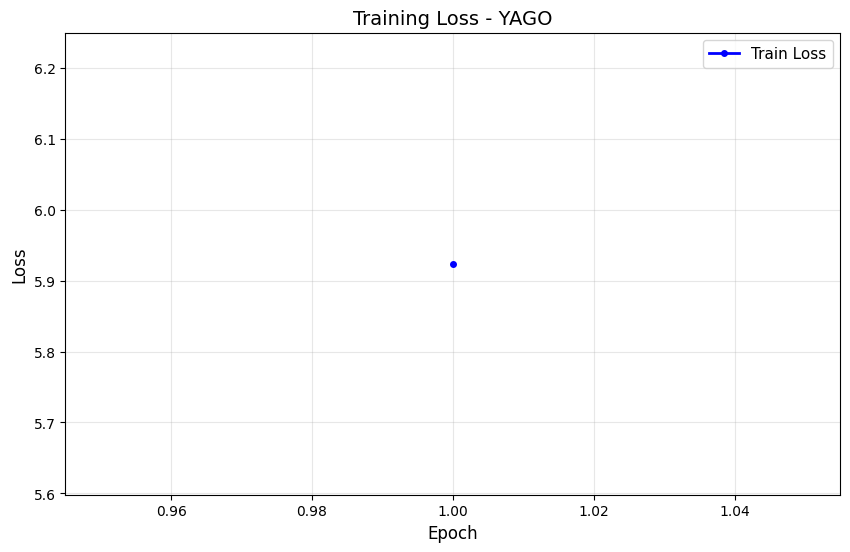

In [ ]:
metrics_file = os.path.join(main_dirName, 'metrics.csv')

if os.path.exists(metrics_file):
    # Read metrics from CSV
    df = pd.read_csv(metrics_file)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot training loss
    ax.plot(df['Epoch'], df['Train Loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training Loss - {system_config["dataset"]}', fontsize=14)
    
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Save plot
    plot_file = os.path.join(main_dirName, 'loss_plot.png')
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"Loss plot saved to: {plot_file}")
    
    # Display plot
    plt.show()
else:
    print(f"Metrics file not found: {metrics_file}")

Loss plot saved to: SAVE/version_3_YAGO/val_loss_plot.png


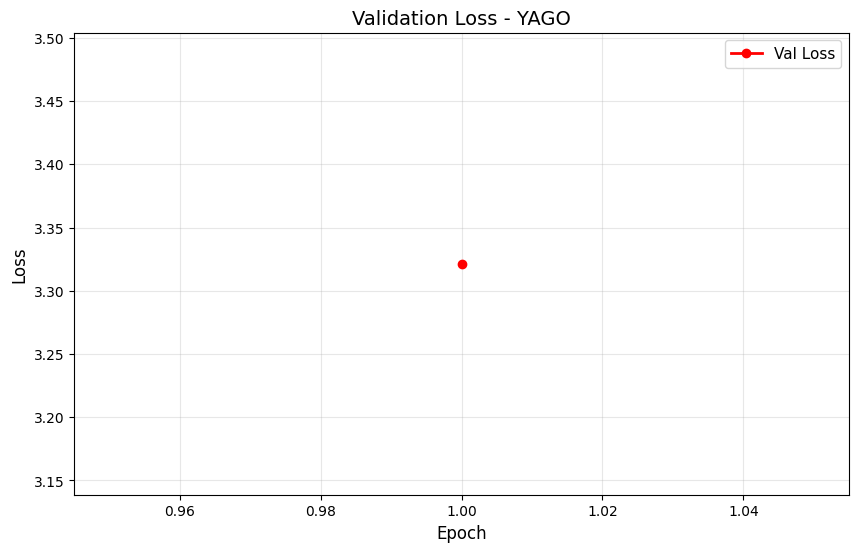

In [39]:
import matplotlib.pyplot as plt

metrics_file = os.path.join(main_dirName, 'metrics.csv')

if os.path.exists(metrics_file):
    # Read metrics from CSV
    df = pd.read_csv(metrics_file)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Filter out NaN values for Val Loss
    valid_data = df.dropna(subset=['Val Loss'])
    
    # Plot validation loss (only non-NaN points)
    ax.plot(valid_data['Epoch'], valid_data['Val Loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Validation Loss - {system_config["dataset"]}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Save plot
    plot_file = os.path.join(main_dirName, 'val_loss_plot.png')

    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"Loss plot saved to: {plot_file}")
    
    # Display plot
    plt.show()
else:
    print(f"Metrics file not found: {metrics_file}")